In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("../data/processed/tb_cleaned.csv")
df.head()

,country,code,year,tb_cases,tb_incidence_per_100k
0,Afghanistan,AFG,2000,30000.0,148.0
1,Afghanistan,AFG,2001,35000.0,175.0
2,Afghanistan,AFG,2002,42000.0,197.0
3,Afghanistan,AFG,2003,49000.0,215.0
4,Afghanistan,AFG,2004,54000.0,228.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5592 entries, 0 to 5591
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                5592 non-null   object 
 1   code                   5592 non-null   object 
 2   year                   5592 non-null   int64  
 3   tb_cases               5592 non-null   float64
 4   tb_incidence_per_100k  5592 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 218.6+ KB


In [3]:
df.describe()

,year,tb_cases,tb_incidence_per_100k
count,5592.000000,5.592000e+03,5592.000000
mean,2012.049177,2.001541e+05,137.947185
std,7.200870,1.067834e+06,209.935798
min,2000.000000,0.000000e+00,0.000000
25%,2006.000000,3.000000e+02,12.000000
50%,2012.000000,4.000000e+03,56.000000
75%,2018.000000,2.525000e+04,182.000000
max,2024.000000,1.205180e+07,2700.000000


In [4]:
df.isnull().sum()

country                  0
code                     0
year                     0
tb_cases                 0
tb_incidence_per_100k    0
dtype: int64

In [5]:
print("Rows and columns:", df.shape)
print("Total countries:", df["country"].nunique())
print("Year range:", df["year"].min(), "to", df["year"].max())

Rows and columns: (5592, 5)
Total countries: 226
Year range: 2000 to 2024


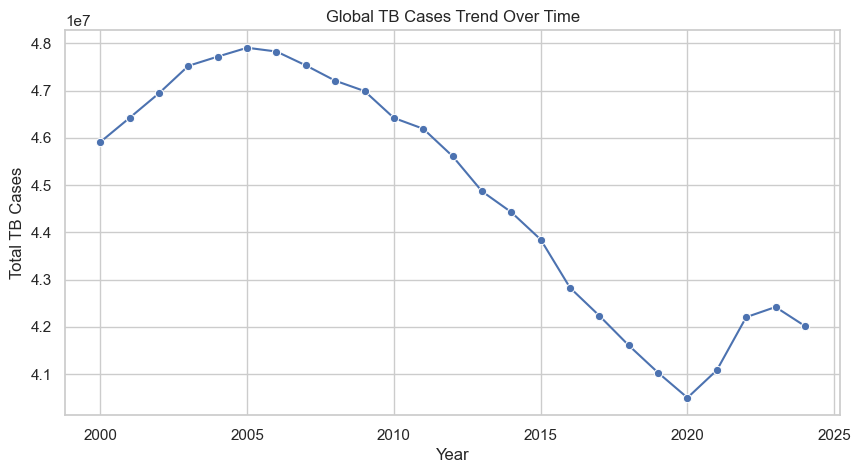

In [6]:
global_trend = df.groupby("year")["tb_cases"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=global_trend, x="year", y="tb_cases", marker="o")
plt.title("Global TB Cases Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total TB Cases")
plt.show()

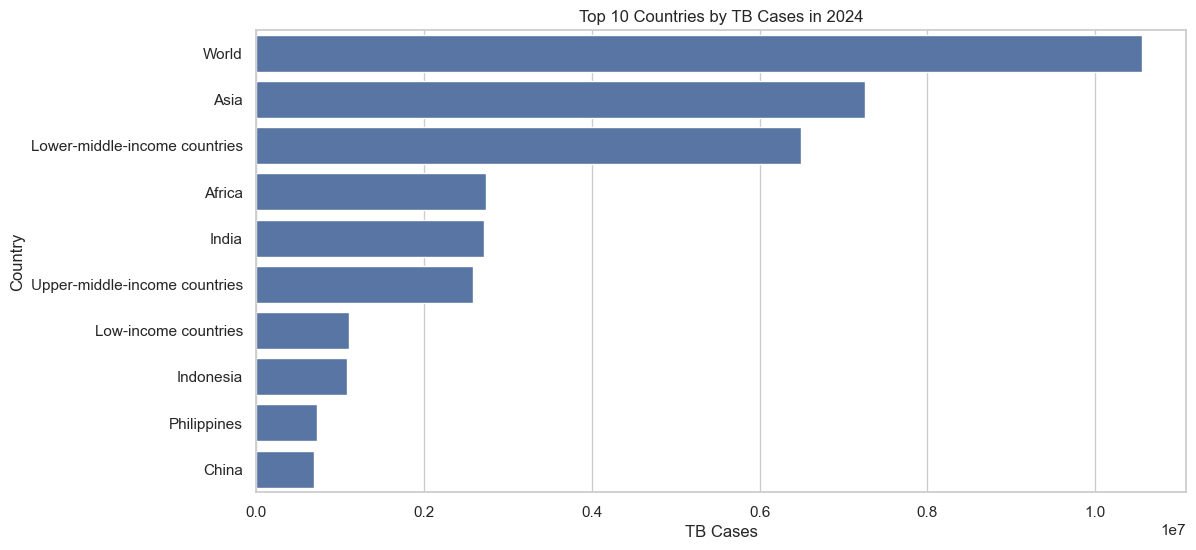

In [7]:
latest_year = df["year"].max()
latest_data = df[df["year"] == latest_year]

top_10_cases = latest_data.sort_values(by="tb_cases", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_cases, x="tb_cases", y="country")
plt.title(f"Top 10 Countries by TB Cases in {latest_year}")
plt.xlabel("TB Cases")
plt.ylabel("Country")
plt.show()